## Consumer financial voice — descriptive marketing intelligence

This notebook builds a **team-shared** view of a **public, multi-source** consumer finance dataset. We treat it as **industry-level** intelligence: who shows up in the data, when, which **issues and products** dominate, and which firms draw volume — **not** as private enterprise CRM analytics.

**What this notebook analyzes (not “everything in the CSV”):** After the load, we keep the full table as **`dfCust`** (for transparency). The **Marketing intelligence descriptives — sections 1–4** and **BI visualizations** use **`df` = CFPB rows only** (`source == "CFPB"`). **Demand signals** and **Complaint drivers** also filter to **CFPB** (plus `customer_complaint` where stated). We do **not** mix app reviews, Trustpilot, or Google Trends into those blocks. **Baseline `info`/`describe`** and **selection-bias** cells use **full `dfCust`** (all sources) on purpose.

**NLP “sentiment”:** The raw CSV may still contain **`sentiment_label` / `sentiment_score`** from the supplier. **This notebook does not treat them as analysis outcomes** (labels like “positive” on complaint text are misleading). Use **`customer_action`**, **`issue`**, **`product_service`**, and **formal-complaint share** instead.

**How to use this file:** **Restart kernel → Run all.** The first code cell **finds the master CSV automatically** (looks for `shared_cleaning_rules.py` in the current folder or parents, then loads `master_customer_behavior_v3-1.csv` or falls back to `master_customer_behavior_clean.csv`). You can run from the **repo root** or **`descriptive/`** without editing paths.

**Key object:** `dfCust` = full cleaned table after the load cell. **Marketing intelligence (sections 1–4)**, **BI visualizations**, **Demand signals**, and **Complaint drivers** use **CFPB-only** slices (see each header). **Baseline `info`/`describe`** and **selection-bias** diagnostics intentionally use **full `dfCust`** (all sources).

**Product / demand direction:** See **Demand signals — product / service direction** for **CFPB + `customer_complaint`** volume tables; then **Complaint drivers — by product & firm salience** for **issues within each product** and **high-salience vs tail firms** (mix + formal-complaint rate by tier).


In [24]:
import pandas as pd
from pathlib import Path

# Resolve CSV whether the notebook cwd is project root, descriptive/, or elsewhere (walk up for repo root).
def _project_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "shared_cleaning_rules.py").is_file():
            return p
    return here


_root = _project_root()
_csv_raw = _root / "master_customer_behavior_v3-1.csv"
_csv_clean = _root / "master_customer_behavior_clean.csv"
if _csv_raw.is_file():
    csv_path = _csv_raw
elif _csv_clean.is_file():
    csv_path = _csv_clean
    print("Note: using master_customer_behavior_clean.csv (v3-1 not next to shared_cleaning_rules.py).\n")
else:
    raise FileNotFoundError(
        f"Missing data CSV. Expected one of:\n  {_csv_raw}\n  {_csv_clean}\n"
        f"(searched from cwd {Path.cwd().resolve()}; project root {_root})"
    )
print(f"Loading: {csv_path}\n")

# utf-8-sig strips BOM on first column name if present
dfCust = pd.read_csv(csv_path, low_memory=False, encoding="utf-8-sig")

# 'rating' is empty for almost all rows → drop from completeness rules
dfCust = dfCust.drop(columns=["rating"], errors="ignore")
print("Dropped column 'rating' from the working table (CSV file on disk is unchanged).\n")

# dropna(how="any") removed EVERY row with a blank in *any* column. For 2018+ many sources
# leave country / url / raw_metadata empty → you kept only ~2014–2017 CFPB-style complete rows.
# Here we only require non-missing values on columns needed for core analysis; optional fields
# can be NaN (you can still use them when present).
ALLOW_NAN_IN_THESE_COLS = ["country", "url", "raw_metadata"]
cols_required = [c for c in dfCust.columns if c not in ALLOW_NAN_IN_THESE_COLS]
rows_before = len(dfCust)
row_has_nan = dfCust[cols_required].isna().any(axis=1)
dropped_indexes = dfCust.index[row_has_nan].tolist()
dfCust = dfCust.loc[~row_has_nan].copy()
rows_after = len(dfCust)

MAX_INDEXES_TO_SHOW = 50
n_dropped = len(dropped_indexes)
print(
    f"Rows before row drop (any NaN in required columns): {rows_before:,} | "
    f"after: {rows_after:,} (removed {n_dropped:,})"
)
print(
    f"Required non-NaN columns ({len(cols_required)}): "
    f"all except {ALLOW_NAN_IN_THESE_COLS} (change list to tighten/relax).\n"
)
if n_dropped == 0:
    print("Dropped row indexes: (none)")
elif n_dropped <= MAX_INDEXES_TO_SHOW:
    print(f"Dropped row indexes ({n_dropped}): {dropped_indexes}")
else:
    print(
        f"Dropped row indexes: {n_dropped:,} total (too many to list; max shown is {MAX_INDEXES_TO_SHOW})"
    )

# Quick sanity: year coverage in the kept data (spot post-2017 anomalies)
print("\nRow counts by year (last 12 calendar years in file):")
_ycounts = dfCust.groupby("year").size()
_ymax = int(_ycounts.index.max())
print(_ycounts[_ycounts.index >= (_ymax - 11)])
print(f"\nYear range in dfCust: {int(dfCust['year'].min())} – {int(dfCust['year'].max())}")

print(dfCust)


Loading: /Users/asauliuk/Library/CloudStorage/OneDrive-SanFranciscoStateUniversity/ISYS812-finalProject/master_customer_behavior_v3-1.csv

Dropped column 'rating' from the working table (CSV file on disk is unchanged).

Rows before row drop (any NaN in required columns): 788,962 | after: 777,867 (removed 11,095)
Required non-NaN columns (12): all except ['country', 'url', 'raw_metadata'] (change list to tighten/relax).

Dropped row indexes: 11,095 total (too many to list; max shown is 50)

Row counts by year (last 12 calendar years in file):
year
2015    169055
2016    191843
2017    243188
2018       402
2019       257
2020       259
2021       276
2022       394
2023       326
2024       429
2025      2014
2026     14062
dtype: int64

Year range in dfCust: 2010 – 2026
        record_id         source        date  year  month  \
0               1           CFPB  29-08-2014  2014      8   
1               2           CFPB  09-10-2014  2014     10   
2               3           CFPB  25

### Enrich `dfCust` (parsed fields)

The next cell adds **`issue`** and **`trends_keyword`** from `raw_metadata`, and **`sentiment_revised_label`** only so **`dfCust` matches the clean export schema** (`shared_cleaning_rules`). **We do not interpret NLP sentiment or “positive” labels in this notebook** — they confuse readers on short CFPB text. Main analysis uses **`customer_action`**, **issue**, and **product**.

Run **after** the load cell.

In [25]:
import sys
from pathlib import Path

# Repo root (notebook may run from project root or descriptive/)
_root = Path.cwd().resolve()
if _root.name == "descriptive":
    _root = _root.parent
sys.path.insert(0, str(_root))

from shared_cleaning_rules import add_issue_from_metadata, add_revised_sentiment, add_trends_keyword

_df = dfCust.copy()
if "issue" not in _df.columns or _df["issue"].isna().all():
    _df = add_issue_from_metadata(_df)
_df = add_revised_sentiment(_df)
_df = add_trends_keyword(_df)

dfCust = _df
print(
    "Enriched dfCust: issue, trends_keyword, sentiment_revised_label "
    "(export/schema parity only — not used in notebook tables or charts)."
)


Enriched dfCust: issue, trends_keyword, sentiment_revised_label (export/schema parity only — not used in notebook tables or charts).


## Analysis sample (`dfCust`)

The **load cell above** **reads the CSV**, **drops the empty `rating` column**, then removes rows that still have **missing values in required fields**. We **allow** missing values in **`country`**, **`url`**, and **`raw_metadata`** so newer sources (often sparse there) are not deleted entirely — otherwise the timeline would collapse to ~2014–2017 only.

**Why it matters:** everyone downstream should know **which rows exist** in **`dfCust`** before interpreting counts and shares. The **Marketing intelligence descriptives (sections 1–4)** and **BI visualizations** use a **CFPB-only** slice; **Demand signals** and **Complaint drivers** also filter to **CFPB** (plus `customer_complaint` where noted). The load cell prints **before/after row counts** and a **year distribution** on **full `dfCust`** (all sources in file).


## Demand signals — product / service direction *(runnable section)*

**Purpose:** Turn **CFPB + `customer_complaint`** rows into **tables you can scan** for **where pain concentrates** — by **product**, **issue**, **firm salience**, **customer action**, and **time**. Use this to brainstorm **what to build** (features, automation, positioning), not as proof of total market size.

**Slice:** `event_type == "customer_complaint"` **and** `source == "CFPB"` (structured complaint channel aligned with the main finance MI narrative). Other sources / event types are intentionally **out of scope** in this block.

**How to run:** run the **CSV load** cell, then the **enrichment** cell (`issue`, `trends_keyword`, export-parity columns), then **this cell**. Or **Restart kernel → Run all** from the top.

---

In [26]:
# =============================================================================
# Demand signals — CFPB + customer_complaint slice (product / issue / firm / time)
# =============================================================================
import numpy as np
import pandas as pd
from IPython.display import display

# Requires dfCust from load + shared cleaning cell (issue, etc.)
df = dfCust

MASK = (df["event_type"].astype(str) == "customer_complaint") & (
    df["source"].astype(str) == "CFPB"
)
d = df.loc[MASK].copy()
n = len(d)

print("=== Demand signals (CFPB + customer_complaint) ===\n")
print(f"Rows in slice: {n:,}")
if n == 0:
    raise SystemExit("No rows — check filters or run load + cleaning cells first.")

# --- 1) Dominant (product_service × issue) pairs ---
pair = (
    d.groupby(["product_service", "issue"], observed=True)
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
)
pair["pct_of_slice"] = (100 * pair["n"] / n).round(2)
print("\n--- Top 25 product × issue pairs (counts + % of this slice) ---")
display(pair.head(25))

# --- 2) Product and issue marginals ---
print("\n--- Top 15 product_service (volume in slice) ---")
display(d["product_service"].value_counts().head(15).to_frame("n"))

print("\n--- Top 20 issue (volume in slice) ---")
display(d["issue"].value_counts().head(20).to_frame("n"))

# --- 3) Formal complaint share by product (escalation intensity proxy) ---
fc = d["customer_action"].astype(str).eq("formal_complaint")
by_prod = (
    d.assign(_fc=fc)
    .groupby("product_service", observed=True)
    .agg(
        n=("_fc", "size"),
        formal_complaint_pct=("_fc", lambda s: np.round(100 * s.mean(), 2)),
    )
    .sort_values("n", ascending=False)
)
print("\n--- Top 15 products by volume — % formal_complaint within slice ---")
display(by_prod.head(15))

# --- 4) customer_action mix (whole slice) ---
print("\n--- customer_action mix (this slice) ---")
act = d["customer_action"].value_counts(normalize=True).mul(100).round(2)
display(pd.DataFrame({"pct": act}))

# --- 5) Top issues × customer_action (top 12 issues only) ---
top_issues = d["issue"].value_counts().head(12).index.tolist()
sub = d[d["issue"].isin(top_issues)]
ct = pd.crosstab(sub["issue"], sub["customer_action"], margins=False)
print("\n--- Top 12 issues × customer_action (raw counts) ---")
display(ct)

# --- 6) Firm salience: top 20 companies by volume ---
co_n = d["company"].value_counts()
top20 = co_n.head(20)
print("\n--- Top 20 companies by complaint rows (salience in this data) ---")
display(top20.to_frame("n"))

# Proxy tier for "high salience" vs long tail (data-driven, not market cap)
top20_set = set(top20.index)
d2 = d.assign(
    firm_tier=lambda x: x["company"].map(
        lambda c: "top20_in_data" if c in top20_set else "tail"
    )
)
_rows = []
for tier in ["top20_in_data", "tail"]:
    vc = d2.loc[d2["firm_tier"] == tier, "issue"].value_counts().head(8)
    for issue, cnt in vc.items():
        _rows.append({"firm_tier": tier, "issue": issue, "n": cnt})
mix = pd.DataFrame(_rows)
print("\n--- Top issues: top20_in_data vs tail firms (row counts) ---")
display(mix)

# --- 7) Time: volume by year + top 5 issues per recent year ---
print("\n--- Rows by year (slice) ---")
display(d.groupby("year").size().to_frame("n"))

_years = sorted(d["year"].dropna().unique().tolist())
_recent = _years[-6:] if len(_years) > 6 else _years
print("\n--- Top 5 issues per year (recent years in data) ---")
for y in _recent:
    top5 = d[d["year"] == y]["issue"].value_counts().head(5)
    print(f"\nYear {int(y)}:")
    display(top5.to_frame("n"))

print("\nDone — see markdown section **Demand signals — product / service direction** above for interpretation.")


=== Demand signals (CFPB + customer_complaint) ===

Rows in slice: 755,671

--- Top 25 product × issue pairs (counts + % of this slice) ---


,product_service,issue,n,pct_of_slice
90,Credit reporting,Incorrect information on credit report,91926,12.16
148,Mortgage,"Loan modification,collection,foreclosure",60384,7.99
111,Debt collection,Cont'd attempts collect debt not owed,56223,7.44
149,Mortgage,"Loan servicing, payments, escrow account",54024,7.15
101,"Credit reporting, credit repair services, or o...",Incorrect information on your report,36300,4.80
112,Debt collection,Disclosure verification of debt,28823,3.81
0,Bank account or service,"Account opening, closing, or management",27302,3.61
110,Debt collection,Communication tactics,25397,3.36
210,Student loan,Dealing with my lender or servicer,17545,2.32
1,Bank account or service,Deposits and withdrawals,15680,2.07



--- Top 15 product_service (volume in slice) ---


,n
product_service,
Debt collection,167116
Mortgage,157325
Credit reporting,124176
"Credit reporting, credit repair services, or other personal consumer reports",73375
Bank account or service,60604
Credit card,59471
Student loan,34029
Consumer Loan,26471
Credit card or prepaid card,15401



--- Top 20 issue (volume in slice) ---


...


Year 2016:


,n
issue,
Incorrect information on credit report,32570
"Loan servicing, payments, escrow account",17030
Cont'd attempts collect debt not owed,16685
"Loan modification,collection,foreclosure",16247
Disclosure verification of debt,10370



Year 2017:


,n
issue,
Incorrect information on your report,37962
Problem with a credit reporting company's investigation into an existing problem,15851
Improper use of your report,15710
Attempts to collect debt not owed,13137
Incorrect information on credit report,12305



Done — see markdown section **Demand signals — product / service direction** above for interpretation.


## Complaint drivers — by product & firm salience *(runnable section)*

**Purpose:** Go one level deeper than volume counts: **which `issue` types sit under each `product_service`**, and how **high-volume firms in this file** differ from the **long tail** in **issue mix** and **product mix**.

**Slice:** **`source == "CFPB"`** and **`event_type == "customer_complaint"`** (same structured-complaint channel as **Demand signals**).

**“Big” vs “small” (important):** The data do **not** include assets or revenue. **“High salience”** = firms in the **top K by row count** in this slice; **“tail”** = all other firms. That measures **who dominates the complaint *file***, not formal market size — say so in any write-up.

**How to run:** after **load**, **enrichment**, and ideally **Demand signals** (same `dfCust`). **Restart kernel → Run all** is fine.

---

In [27]:
# =============================================================================
# Complaint drivers: by product_service + high-salience vs tail firms (CFPB complaints)
# =============================================================================
import numpy as np
import pandas as pd
from IPython.display import display

# Tunables (adjust for slides vs appendix)
TOP_PRODUCTS = 10
TOP_ISSUES_PER_PRODUCT = 10
TOP_K_SALIENCE_FIRMS = 30

d = dfCust[
    (dfCust["source"].astype(str) == "CFPB")
    & (dfCust["event_type"].astype(str) == "customer_complaint")
].copy()
n = len(d)
print("=== Complaint drivers (CFPB + customer_complaint) ===\n")
print(f"Rows: {n:,}")
if n == 0:
    raise SystemExit("No rows — run load + enrichment first.")

# --- A) Within each major product: which issues dominate? ---
prod_n = d["product_service"].value_counts()
top_prods = prod_n.head(TOP_PRODUCTS).index.tolist()
print(f"\n--- A) Top {TOP_ISSUES_PER_PRODUCT} issues *within* each of the top {TOP_PRODUCTS} products (% of rows for that product) ---\n")
for p in top_prods:
    sub = d[d["product_service"] == p]
    m = len(sub)
    if m == 0:
        continue
    vc = sub["issue"].value_counts().head(TOP_ISSUES_PER_PRODUCT)
    tbl = vc.rename_axis("issue").reset_index(name="n")
    tbl["pct_within_product"] = np.round(100 * tbl["n"] / m, 2)
    print(f"product_service = {p!r}  (n={m:,})")
    display(tbl)
    print()

# --- B) Product × issue pairs (top 30) — same lens as Demand signals, ranked here by product ---
pair = (
    d.groupby(["product_service", "issue"], observed=True)
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
)
pair["pct_of_slice"] = np.round(100 * pair["n"] / n, 2)
print(f"--- B) Top 30 product × issue pairs (% of this slice) ---")
display(pair.head(30))

# --- C) High salience vs tail firms (row-count proxy, not market cap) ---
co_counts = d["company"].value_counts()
top_firms = set(co_counts.head(TOP_K_SALIENCE_FIRMS).index)
d["firm_salience"] = np.where(
    d["company"].isin(top_firms),
    f"top_{TOP_K_SALIENCE_FIRMS}_by_rows",
    "tail_firms",
)

print(
    f"\n--- C) Firm tiers: top {TOP_K_SALIENCE_FIRMS} companies by row count vs tail "
    f"(interpret as salience in *this file*) ---"
)
print(d["firm_salience"].value_counts().to_string())
print()

# Issue mix: % of rows in each tier (same issues, comparable columns)
hi = d.loc[d["firm_salience"] != "tail_firms"]
lo = d.loc[d["firm_salience"] == "tail_firms"]
hi_iss = hi["issue"].value_counts(normalize=True).mul(100).round(2)
lo_iss = lo["issue"].value_counts(normalize=True).mul(100).round(2)
issue_cmp = (
    pd.concat([hi_iss, lo_iss], axis=1, keys=["high_salience_pct", "tail_pct"])
    .fillna(0)
    .sort_values("high_salience_pct", ascending=False)
)
issue_cmp["diff_pp"] = (issue_cmp["high_salience_pct"] - issue_cmp["tail_pct"]).round(2)
print("--- C1) Issue mix (% of rows within each tier) — sorted by high-salience share ---")
display(issue_cmp.head(25))

print("--- C2) Issues *more* concentrated among high-salience firms (largest positive diff_pp) ---")
display(issue_cmp.sort_values("diff_pp", ascending=False).head(15))

print("--- C3) Issues *more* concentrated among tail firms (largest negative diff_pp) ---")
display(issue_cmp.sort_values("diff_pp", ascending=True).head(15))

# Product mix by tier (% of rows within tier)
hi_p = hi["product_service"].value_counts(normalize=True).mul(100).round(2)
lo_p = lo["product_service"].value_counts(normalize=True).mul(100).round(2)
prod_cmp = (
    pd.concat([hi_p, lo_p], axis=1, keys=["high_salience_pct", "tail_pct"])
    .fillna(0)
    .sort_values("high_salience_pct", ascending=False)
)
prod_cmp["diff_pp"] = (prod_cmp["high_salience_pct"] - prod_cmp["tail_pct"]).round(2)
print("--- C4) Product mix by tier (% within tier) ---")
display(prod_cmp.head(20))

# Formal complaint rate by tier (behavior, not NLP)
fc = d["customer_action"].astype(str) == "formal_complaint"
tier_fc = (
    d.assign(_fc=fc)
    .groupby("firm_salience", observed=True)
    .agg(n_rows=("_fc", "size"), formal_complaint_pct=("_fc", lambda s: np.round(100 * s.mean(), 2)))
)
print("--- C5) Formal complaint % by firm tier ---")
display(tier_fc)

print(
    "\nDone — interpret **high salience** as **who fills this dataset**, then link "
    "**product × issue** tables to **unmet need / product direction** in your narrative."
)


=== Complaint drivers (CFPB + customer_complaint) ===

Rows: 755,671

--- A) Top 10 issues *within* each of the top 10 products (% of rows for that product) ---

product_service = 'Debt collection'  (n=167,116)


,issue,n,pct_within_product
0,Cont'd attempts collect debt not owed,56223,33.64
1,Disclosure verification of debt,28823,17.25
2,Communication tactics,25397,15.20
3,False statements or representation,13753,8.23
4,Attempts to collect debt not owed,13137,7.86
5,Improper contact or sharing of info,9188,5.50
6,Written notification about debt,8264,4.95
7,Taking/threatening an illegal action,8134,4.87
8,Took or threatened to take negative or legal a...,3305,1.98
9,Threatened to contact someone or share informa...,892,0.53



product_service = 'Mortgage'  (n=157,325)


,issue,n,pct_within_product
0,"Loan modification,collection,foreclosure",60384,38.38
1,"Loan servicing, payments, escrow account",54024,34.34
2,"Application, originator, mortgage broker",10930,6.95
3,Trouble during payment process,7845,4.99
4,Struggling to pay mortgage,7690,4.89
5,Settlement process and costs,5907,3.75
6,Credit decision / Underwriting,3672,2.33
7,Other,3169,2.01
8,Applying for a mortgage or refinancing an exis...,1870,1.19
9,Closing on a mortgage,1359,0.86



product_service = 'Credit reporting'  (n=124,176)


...

--- C4) Product mix by tier (% within tier) ---


,high_salience_pct,tail_pct,diff_pp
product_service,,,
Credit reporting,23.96,1.73,22.23
Mortgage,22.12,18.28,3.84
"Credit reporting, credit repair services, or other personal consumer reports",13.17,2.95,10.22
Credit card,10.92,1.91,9.01
Bank account or service,8.62,6.85,1.77
Debt collection,8.36,49.00,-40.64
Student loan,4.88,3.78,1.10
Credit card or prepaid card,2.60,0.94,1.66
Consumer Loan,2.17,6.10,-3.93


--- C5) Formal complaint % by firm tier ---


,n_rows,formal_complaint_pct
firm_salience,,
tail_firms,255807,98.69
top_30_by_rows,499864,97.30



Done — interpret **high salience** as **who fills this dataset**, then link **product × issue** tables to **unmet need / product direction** in your narrative.


### Post-2017 sample size (for the write-up)

The next cell counts rows with **`year > 2017`** on **full `dfCust`** (all sources — same denominator as the load). That keeps one **file-wide** post-2017 *n* for the write-up. **CFPB-only** post-2017 counts are **smaller**; if you need them, subset **`dfCust`** to rows where **`source`** is CFPB before counting. Interpretation uses an informal **1,500-row** floor for *aggregate* summaries (rule of thumb, not formal power).

**Why it matters:** teammates can align on whether late-year slices are **big enough to summarise** at the aggregate level, while still noting **sparse quarters** or small subgroups.

In [28]:
# Post-2017 sample size (for reporting)
# Informal floor N_MIN: rough guide for *aggregate* descriptive summaries (not a universal law;
# hypothesis tests / small subgroups / rare categories may need more — see markdown text).
from IPython.display import Markdown, display

N_MIN = 1500
post_mask = dfCust["year"] > 2017
n_post = int(post_mask.sum())
n_total = int(len(dfCust))
pct_post = 100.0 * n_post / n_total if n_total else 0.0
# Weakest single year after 2017 (for extra transparency)
post_years = dfCust.loc[post_mask, "year"]
yr_counts = post_years.value_counts().sort_index()
n_min_year = int(yr_counts.min()) if len(yr_counts) else 0
min_year_label = int(yr_counts.idxmin()) if len(yr_counts) else None

print(f"Rows with year > 2017: {n_post:,} ({pct_post:.2f}% of full dfCust — all sources)")
post_cfpb = int(((dfCust["source"].astype(str) == "CFPB") & (dfCust["year"] > 2017)).sum())
print(f"CFPB-only rows with year > 2017: {post_cfpb:,}")
if min_year_label is not None:
    print(f"Smallest single-year count (post-2017): {n_min_year:,} (year {min_year_label})")

if n_post < N_MIN:
    display(
        Markdown(
            f"""
### Post-2017 sample size

The subsample with **year > 2017** contains **{n_post:,}** rows (**full `dfCust`, all sources**), which is **below** the informal **{N_MIN:,}-row** floor used in this notebook for treating **aggregate** descriptive summaries as reliably stable.

**Implication:** treat **2018+** statistics as **exploratory** unless you justify a lower threshold for your metric, combine years, or widen eligibility rules.

*Note: {N_MIN:,} is a coarse rule of thumb (e.g. comfort with large-sample approximations for simple proportions); it is not a substitute for a formal power analysis.*
"""
        )
    )
else:
    display(
        Markdown(
            f"""
### Post-2017 sample size

The subsample with **year > 2017** contains **{n_post:,}** rows (**{pct_post:.1f}%** of full **`dfCust`**, all sources), which **meets or exceeds** the informal **{N_MIN:,}-row** floor used here for **aggregate** descriptive statistics (means, shares, counts pooled across 2018+).

**Despite lower volume than 2014–2017**, this **post-2017 pool is large enough** for **stable high-level summaries** at the full-period level. **Caveats remain:** quarterly charts can still look sparse, **source/channel mix** may differ from the CFPB-heavy era, and **subgroups** (single year, single company, single quarter) can be small—check *n* before over-interpreting.

*Note: the {N_MIN:,}-row guideline targets coarse aggregates, not every slice; rare categories or formal inference may need additional justification.*
"""
        )
    )


Rows with year > 2017: 18,419 (2.37% of full dfCust — all sources)
CFPB-only rows with year > 2017: 0
Smallest single-year count (post-2017): 257 (year 2019)



### Post-2017 sample size

The subsample with **year > 2017** contains **18,419** rows (**2.4%** of full **`dfCust`**, all sources), which **meets or exceeds** the informal **1,500-row** floor used here for **aggregate** descriptive statistics (means, shares, counts pooled across 2018+).

**Despite lower volume than 2014–2017**, this **post-2017 pool is large enough** for **stable high-level summaries** at the full-period level. **Caveats remain:** quarterly charts can still look sparse, **source/channel mix** may differ from the CFPB-heavy era, and **subgroups** (single year, single company, single quarter) can be small—check *n* before over-interpreting.

*Note: the 1,500-row guideline targets coarse aggregates, not every slice; rare categories or formal inference may need additional justification.*


## Baseline column profile

The next cell runs **`info()`** and **`describe()`** on **`dfCust` (all sources)**. This is a **technical sanity pass**: dtypes, non-null counts, and basic numeric/text summaries for the **full** cleaned table.

**Why it matters:** catches parsing issues and missingness before interpretation. **Sections 1–4** and **BI visualizations** use **CFPB-only** slices; this **`info`/`describe`** is on **full `dfCust`** on purpose so you see **all sources** in the file.


In [29]:
# Descriptive analysis (after removing rows with any NaN)
print("Column dtypes and non-null counts:")
dfCust.info()
print()
print("Numeric columns — summary statistics:")
display(dfCust.describe())
print()
print("Categorical / text columns — counts & top values:")
display(dfCust.describe(include="object"))

Column dtypes and non-null counts:
<class 'pandas.core.frame.DataFrame'>
Index: 777867 entries, 0 to 788961
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   record_id                777867 non-null  int64  
 1   source                   777867 non-null  object 
 2   date                     777867 non-null  object 
 3   year                     777867 non-null  int64  
 4   month                    777867 non-null  int64  
 5   company                  777867 non-null  object 
 6   product_service          777867 non-null  object 
 7   event_type               777867 non-null  object 
 8   text                     777867 non-null  object 
 9   sentiment_score          777867 non-null  float64
 10  sentiment_label          777867 non-null  object 
 11  customer_action          777867 non-null  object 
 12  url                      775165 non-null  object 
 13  country                  7509

,record_id,year,month,sentiment_score
count,777867.000000,777867.000000,777867.000000,777867.000000
mean,389137.075392,2015.913281,6.471897,0.091553
std,224897.134870,1.856683,3.422462,0.405969
min,1.000000,2010.000000,1.000000,-1.000000
25%,194467.500000,2015.000000,3.000000,-0.100200
50%,388934.000000,2016.000000,7.000000,0.000000
75%,583400.500000,2017.000000,9.000000,0.636900
max,788962.000000,2026.000000,12.000000,1.000000



Categorical / text columns — counts & top values:


,source,date,company,product_service,event_type,text,sentiment_label,customer_action,url,country,raw_metadata,issue,sentiment_revised_label,trends_keyword
count,777867,777867,777867,777867,777867,777867,777867,777867,775165,750930,777867,755671,777867,2702
unique,6,2733,4546,45,4,13330,3,16,2488,63,758564,162,3,14
top,CFPB,23-02-2026,"EQUIFAX, INC.",Debt collection,customer_complaint,Incorrect information on credit report. Credit...,positive,formal_complaint,https://www.consumerfinance.gov/data-research/...,CA,"{""rating"": null, ""reviewer_country"": null}",Incorrect information on credit report,negative,cancel Netflix
freq,755671,3786,68665,167116,755671,91926,283106,738840,755671,103712,5459,91926,758157,193


## Marketing intelligence descriptives (pandas / numpy)

**Scope:** Sections **1–4** set **`df` = CFPB only** (`dfCust[source == "CFPB"]`). **Non-CFPB sources are not included** in these tables (**same CFPB slice as BI visualizations**). Headline metrics use **`customer_action`** and **formal complaint share**, not supplier NLP sentiment.

**Noise at company level:** Section 4 uses a **minimum row count** so tiny firms do not dominate rankings.

**Dates:** `date` is parsed with `dayfirst=True` (e.g. `29-08-2014`).

Run the cells below **after** `dfCust` exists (load + shared cleaning cell above).

### 1 — Dataset overview (CFPB only)

**What we analyse:** size of the **CFPB** sample, **date range**, **unique companies and product lines**, **monthly volume**. The code fixes **`source == "CFPB"`** — there is no multi-source mix in this section.

**Why it matters for MI:** establishes **coverage and credibility** for the **regulatory-complaint** lens (who, when, how much volume).


In [30]:
# =============================================================================
# 1) Dataset overview
# =============================================================================
import numpy as np
import pandas as pd
from IPython.display import display

# Assumes dfCust is already loaded and cleaned (e.g. rating dropped, dropna applied).
# CFPB-only: coherent finance / complaint slice (see Marketing intelligence header above).
_df_all_n = len(dfCust)
df = dfCust[dfCust["source"].astype(str) == "CFPB"].copy()

# Total rows in this section's analysis sample
total_rows = len(df)
print("=== 1. Dataset overview (CFPB only) ===\n")
print(f"Rows in df (CFPB): {total_rows:,}  |  rows in dfCust (all sources): {_df_all_n:,}")

# Date range: strings are often DD-MM-YYYY in this file → dayfirst=True
parsed_dates = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
bad_dates = int(parsed_dates.isna().sum())
print(f"Date range (min → max): {parsed_dates.min()} → {parsed_dates.max()}")
if bad_dates:
    print(f"(Rows where date could not be parsed: {bad_dates:,})")

# Distinct firms and product lines (marketing-relevant breadth)
n_companies = df["company"].nunique()
n_products = df["product_service"].nunique()
print(f"Unique companies: {n_companies:,}")
print(f"Unique product_service categories: {n_products:,}")

# Monthly volume: combine year + month into a sortable label (YYYY-MM)
ym_key = (
    df["year"].astype(str)
    + "-"
    + df["month"].astype(int).astype(str).str.zfill(2)
)
monthly_volume = ym_key.value_counts().sort_index()
monthly_volume.name = "record_count"
print("\nSource check (should be CFPB only):")
display(df["source"].value_counts().to_frame("n"))

print("\nMonthly record volume (year-month):")
display(monthly_volume.to_frame())

=== 1. Dataset overview (CFPB only) ===

Rows in df (CFPB): 755,671  |  rows in dfCust (all sources): 777,867
Date range (min → max): 2014-01-01 00:00:00 → 2017-12-31 00:00:00
Unique companies: 4,522
Unique product_service categories: 18

Source check (should be CFPB only):


,n
source,
CFPB,755671



Monthly record volume (year-month):


,record_count
2014-01,12617
2014-02,13048
2014-03,13942
2014-04,13838
2014-05,12163
2014-06,12512
2014-07,13406
2014-08,13182
2014-09,12461
2014-10,12897


### 2 — Customer action (CFPB only)

**What we analyse:** **`customer_action`** distribution on the CFPB slice (`df`), **formal complaint share** overall and **by company** (top/bottom tables). **Supplier NLP sentiment is omitted** — it is not a reliable read on this text.


In [31]:
# =============================================================================
# 2) Customer action + formal complaint rate (CFPB only; df from section 1)
# =============================================================================
is_fc = df["customer_action"].astype(str) == "formal_complaint"

print("=== 2. Customer action (CFPB) ===\n")

print("customer_action — counts and % of CFPB rows:")
act_ct = df["customer_action"].value_counts()
act_pct = (df["customer_action"].value_counts(normalize=True) * 100).round(2)
display(pd.DataFrame({"n": act_ct, "pct": act_pct}))

print(f"\nFormal complaint share (all CFPB rows in df): {100 * is_fc.mean():.2f}%")

# Formal complaint rate by company (same MIN_ROWS idea as section 4)
MIN_ROWS_2 = 10
fc_rate_co = (
    df.assign(_fc=is_fc)
    .groupby("company", observed=True)
    .agg(
        n_rows=("_fc", "size"),
        formal_complaint_pct=("_fc", lambda s: np.round(100 * s.mean(), 2)),
    )
    .sort_values("formal_complaint_pct", ascending=False)
)
print(f"\nFormal complaint % by company (min {MIN_ROWS_2} rows) — top 25:")
display(fc_rate_co[fc_rate_co["n_rows"] >= MIN_ROWS_2].head(25))

print(f"\nFormal complaint % by company (min {MIN_ROWS_2} rows) — bottom 25 among qualifying:")
qual = fc_rate_co[fc_rate_co["n_rows"] >= MIN_ROWS_2]
display(qual.tail(25))

=== 2. Customer action (CFPB) ===

customer_action — counts and % of CFPB rows:


,n,pct
customer_action,,
formal_complaint,738840,97.77
complaining,12443,1.65
churning,4388,0.58



Formal complaint share (all CFPB rows in df): 97.77%

Formal complaint % by company (min 10 rows) — top 25:


,n_rows,formal_complaint_pct
company,,
"(Former)Shapiro, Swertfeger & Hasty, LLP",11,100.0
Nationwide Arbitration Services LLC,27,100.0
"National Principal Group, LLC",136,100.0
National Processing Group LLC,13,100.0
"National Recoveries, Inc.",53,100.0
"National Recovery Solutions, LLC",51,100.0
"Nations Direct Mortgage, LLC",28,100.0
Nations Recovery Center,119,100.0
"Nationwide Credit & Collection, Inc.",17,100.0



Formal complaint % by company (min 10 rows) — bottom 25 among qualifying:


,n_rows,formal_complaint_pct
company,,
XOOM CORPORATION,52,80.77
Student Assist Plus LLC,15,80.00
Sigue Corp.,10,80.00
"Intermex Wire Transfer, LLC",10,80.00
Bank of China USA,10,80.00
Blackhawk Network Holdings Inc.,282,78.37
"Remitly, Inc.",27,77.78
"GLOBAL CLIENT SOLUTIONS, LLC",116,77.59
Incomm Holdings Inc.,87,77.01


### 3 — Product, issue, and event type (CFPB only)

**What we analyse:** **`event_type`** (on CFPB this is almost entirely **`customer_complaint`**), **`product_service`** volume, and **top `issue`** categories from metadata.

**Why it matters for MI:** maps **where problems cluster** by product line and issue taxonomy — the same lens as the **Demand signals** section, in compact form.


In [32]:
# =============================================================================
# 3) Product, issue, event_type (CFPB only; df from section 1)
# =============================================================================
is_fc = df["customer_action"].astype(str) == "formal_complaint"

print("=== 3. Product, issue, event_type (CFPB) ===\n")

counts_by_event = df.groupby("event_type", observed=True).size().sort_values(ascending=False)
counts_by_event.name = "record_count"
print("Record count by event_type:")
display(counts_by_event.to_frame())

print("\nTop 15 product_service (volume):")
display(df["product_service"].value_counts().head(15).to_frame("n"))

print("\nTop 20 issue (volume):")
display(df["issue"].value_counts().head(20).to_frame("n"))

# Formal complaint share by event_type (usually one row for CFPB)
fc_by_ev = (
    df.assign(_fc=is_fc)
    .groupby("event_type", observed=True)
    .agg(
        n_rows=("_fc", "size"),
        formal_complaint_pct=("_fc", lambda s: np.round(100 * s.mean(), 2)),
    )
)
print("\nFormal complaint % by event_type:")
display(fc_by_ev)

=== 3. Product, issue, event_type (CFPB) ===

Record count by event_type:


,record_count
event_type,
customer_complaint,755671



Top 15 product_service (volume):


,n
product_service,
Debt collection,167116
Mortgage,157325
Credit reporting,124176
"Credit reporting, credit repair services, or other personal consumer reports",73375
Bank account or service,60604
Credit card,59471
Student loan,34029
Consumer Loan,26471
Credit card or prepaid card,15401



Top 20 issue (volume):


,n
issue,
Incorrect information on credit report,91926
"Loan modification,collection,foreclosure",60384
Cont'd attempts collect debt not owed,56223
"Loan servicing, payments, escrow account",54024
Incorrect information on your report,37962
Disclosure verification of debt,28823
"Account opening, closing, or management",27302
Communication tactics,25397
Dealing with my lender or servicer,17545



Formal complaint % by event_type:


,n_rows,formal_complaint_pct
event_type,,
customer_complaint,755671,97.77


### 4 — Competitive comparison (CFPB only)

**What we analyse:** **share of voice** (% of CFPB rows) by company, combined with **% formal complaint** (`customer_action`) among each firm’s rows, for companies above a **minimum row count**.

**Why it matters for MI:** **who draws volume** in this channel and **how much of that volume is formal complaints** vs other actions — more actionable here than NLP sentiment.


In [33]:
# =============================================================================
# 4) Competitive comparison (share of voice + formal complaint %; CFPB only)
# =============================================================================
# MIN_ROWS filters out companies with too few rows for stable percentages.
MIN_ROWS = 10

print("=== 4. Competitive comparison (CFPB) ===\n")

is_fc = df["customer_action"].astype(str) == "formal_complaint"

# Share of voice = % of CFPB rows mentioning each company
n_total = len(df)
company_counts = df["company"].value_counts()
share_of_voice_pct = np.round(100 * company_counts / n_total, 2)
sov_table = pd.DataFrame(
    {"record_count": company_counts, "share_of_voice_pct": share_of_voice_pct}
)

fc_rate_company = (
    df.assign(_fc=is_fc)
    .groupby("company", observed=True)
    .agg(
        n_rows=("_fc", "size"),
        formal_complaint_pct=("_fc", lambda s: np.round(100 * s.mean(), 2)),
    )
)
fc_for_merge = fc_rate_company[["formal_complaint_pct"]]

competitive = sov_table.join(fc_for_merge, how="left")

competitive_filtered = competitive[competitive["record_count"] >= MIN_ROWS].copy()

competitive_sorted = competitive_filtered.sort_values(
    by=["record_count", "formal_complaint_pct"],
    ascending=[False, False],
)

print(
    f"Share of voice + formal complaint % "
    f"(companies with at least {MIN_ROWS} rows)\n"
)
display(competitive_sorted)

print(
    "\nTip: top rows are high-volume firms in this CFPB slice; higher formal_complaint_pct "
    "means a larger share of that firm’s rows are coded formal_complaint."
)

=== 4. Competitive comparison (CFPB) ===

Share of voice + formal complaint % (companies with at least 10 rows)



,record_count,share_of_voice_pct,formal_complaint_pct
company,,,
"EQUIFAX, INC.",68665,9.09,98.32
Experian Information Solutions Inc.,56759,7.51,98.93
"TRANSUNION INTERMEDIATE HOLDINGS, INC.",53216,7.04,98.85
WELLS FARGO & COMPANY,38716,5.12,98.32
"BANK OF AMERICA, NATIONAL ASSOCIATION",38682,5.12,96.84
...,...,...,...
Quick Debt Services LLC,10,0.00,90.00
"Intermex Wire Transfer, LLC",10,0.00,80.00
Sigue Corp.,10,0.00,80.00



Tip: top rows are high-volume firms in this CFPB slice; higher formal_complaint_pct means a larger share of that firm’s rows are coded formal_complaint.


## Limitations & selection bias (descriptive evidence)

Consumer **voice data** (complaints, public feedback, spikes in search interest) is usually **not a random sample** of all customers. People often **self-select** into leaving a record when something went wrong (negative arousal) or, less often, when they are **very satisfied**—so the mix of tones can **over-represent extremes** relative to “typical” silent satisfaction.

**This does not invalidate** the dataset: it still reflects **real reported experiences** and is useful for monitoring pain points and competitive salience. Counts describe **who showed up in this channel**, not the full population of consumers.

The next cell **quantifies** channel mix (**source**, **event_type**, **customer_action**), and concentration of mentions — so you can cite numbers in your write-up (without leaning on NLP “positive/negative” labels).

## Selection bias — quantitative snapshot

The next cell **measures** **selection and channel effects**: **customer_action** mix, **source** and **event_type**, and **company concentration** (Herfindahl-style). **Supplier sentiment columns are not summarized** here.

**Why it matters:** the dataset reflects **who entered these channels**, not a random sample of all consumers.


In [34]:
# =============================================================================
# Descriptives relevant to selection / channel bias (pandas + numpy only)
# Run after dfCust exists. Uses the FULL pooled table — not the CFPB-only `df` in sections 1–4.
# =============================================================================
import numpy as np
import pandas as pd
from IPython.display import display

df = dfCust

print("=== Selection & channel bias — pooled dfCust (all sources) ===\n")

# --- 1) customer_action (behavior — not NLP sentiment) ---
act = df["customer_action"].value_counts()
act_pct = (act / len(df) * 100).round(2)
print("1) customer_action mix:")
display(pd.DataFrame({"count": act, "pct_of_rows": act_pct}))

fc_share = (df["customer_action"].astype(str) == "formal_complaint").mean() * 100
print(f"\n2) Share of rows with customer_action == formal_complaint: {fc_share:.2f}%")

# --- 3) Channel: source & event_type (what generated the row?) ---
print("\n3) source — who produced the record? (pooled file; includes non-CFPB channels)")
src = df["source"].value_counts()
src_pct = (src / len(df) * 100).round(2)
display(pd.DataFrame({"count": src, "pct_of_rows": src_pct}))

print("\n4) event_type — complaint vs spike vs other mechanisms")
ev = df["event_type"].value_counts()
ev_pct = (ev / len(df) * 100).round(2)
display(pd.DataFrame({"count": ev, "pct_of_rows": ev_pct}))

# --- 5) How concentrated is “voice”? (a few firms absorb most rows) ---
top_n = 10
top_share = df["company"].value_counts().head(top_n).sum() / len(df) * 100
hhi = ((df["company"].value_counts() / len(df)) ** 2).sum() * 10000  # Herfindahl 0–10000 scale
print(f"\n5) Concentration: top {top_n} companies = {np.round(top_share, 2)}% of all rows")
print(f"   Herfindahl index (companies) ≈ {np.round(hhi, 1)} (higher ⇒ mentions less spread out)")

print(
    "\n---\n"
    "Use these tables in prose as: patterns are conditional on this channel and row mix,\n"
    "not as proof of population-wide satisfaction or NLP ‘tone.’"
)

=== Selection & channel bias — pooled dfCust (all sources) ===

1) customer_action mix:


,count,pct_of_rows
customer_action,,
formal_complaint,738840,94.98
complaining,14230,1.83
positive_review,6118,0.79
churning,5708,0.73
negative_review,3766,0.48
advocating,2654,0.34
public_controversy_spike,2374,0.31
researching_price_change,1544,0.20
neutral_review,762,0.10



2) Share of rows with customer_action == formal_complaint: 94.98%

3) source — who produced the record? (pooled file; includes non-CFPB channels)


,count,pct_of_rows
source,,
CFPB,755671,97.15
GooglePlay,8662,1.11
Trustpilot,5459,0.70
AppStore,2999,0.39
Google_Trends,2702,0.35
Wikipedia,2374,0.31



4) event_type — complaint vs spike vs other mechanisms


,count,pct_of_rows
event_type,,
customer_complaint,755671,97.15
app_review,17120,2.20
search_interest_spike,2702,0.35
controversy_article_edit,2374,0.31



5) Concentration: top 10 companies = 47.66% of all rows
   Herfindahl index (companies) ≈ 295.6 (higher ⇒ mentions less spread out)

---
Use these tables in prose as: patterns are conditional on this channel and row mix,
not as proof of population-wide satisfaction or NLP ‘tone.’


## How to read this project (analytical lens)

We are **not** estimating satisfaction for the whole market. A dataset built mainly from **complaints** and **public voice** events captures people who **escalated** or **showed up in this channel**—often because something went wrong. Many satisfied customers **never appear** here.

The right frame is **friction, escalation, and competitive salience** in **financial services**: where **issues** concentrate, which **firms** draw volume, and how **`customer_action`** (e.g. formal complaint vs churn) splits the data.

**In one line:** *this work studies **signals of problems and disputes** in a complaint-heavy sample — useful for **monitoring risk and positioning** — not a census of how happy the average consumer is.*

## BI visualizations (context after formal analysis)

**Purpose:** give stakeholders a **quick visual read** aligned with **Marketing intelligence descriptives (sections 1–4)** — same **CFPB-only** slice, no app/Trends mix in the figures.

**Scope:** charts use **`df = dfCust[source == "CFPB"]`** (printed row count in the code cell). Figures: **quarterly volume**, **customer_action** mix, **product_service**, **event_type** (usually one category here), **top companies**, and **volume vs formal complaint %** (no NLP sentiment charts).

**Note:** **full `dfCust`** still holds other sources for the **baseline `info`/`describe`** cell and the **selection-bias (pooled)** cell — not for these plots. Cite **N** and **2014–2017 CFPB bulk** when presenting.

BI charts: CFPB-only, n = 755,671 rows (dfCust all sources: 777,867)



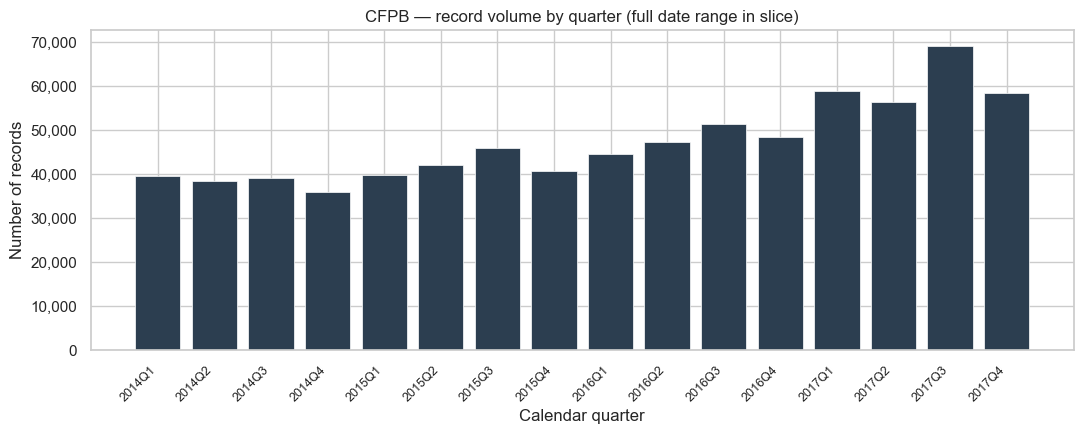

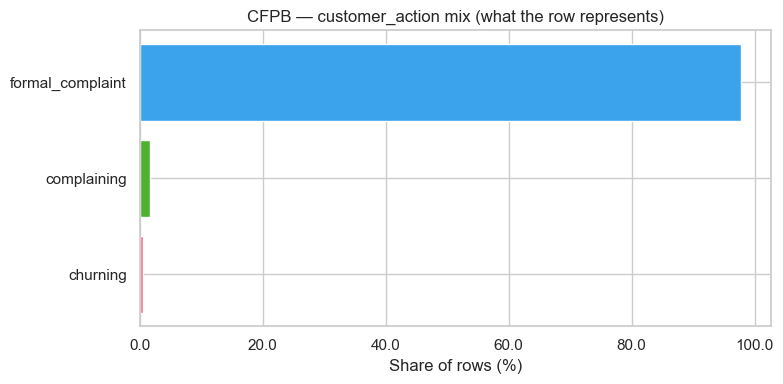

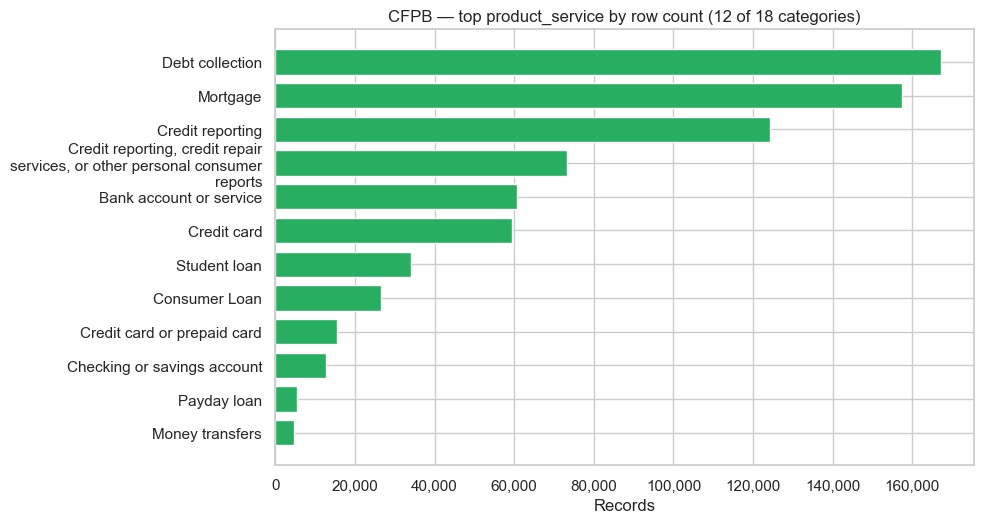

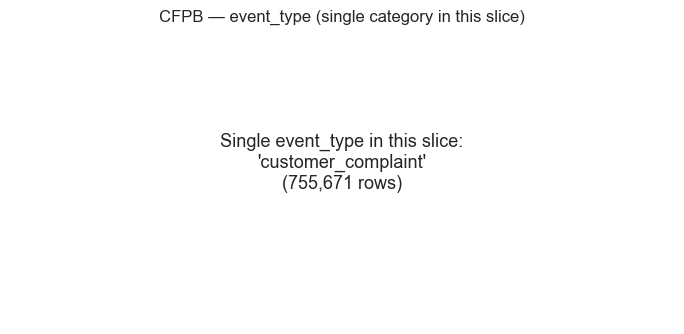

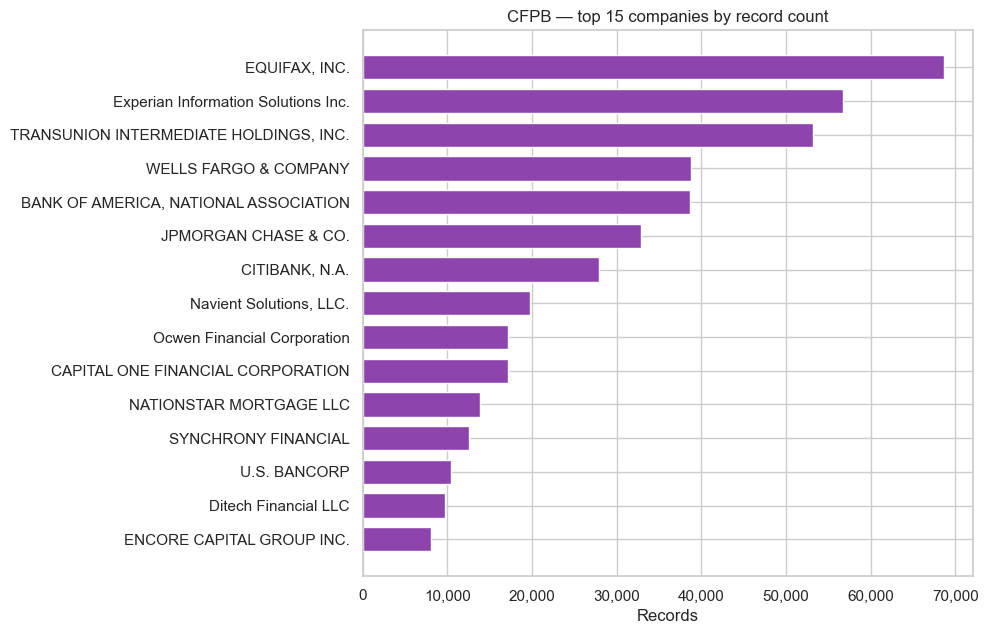

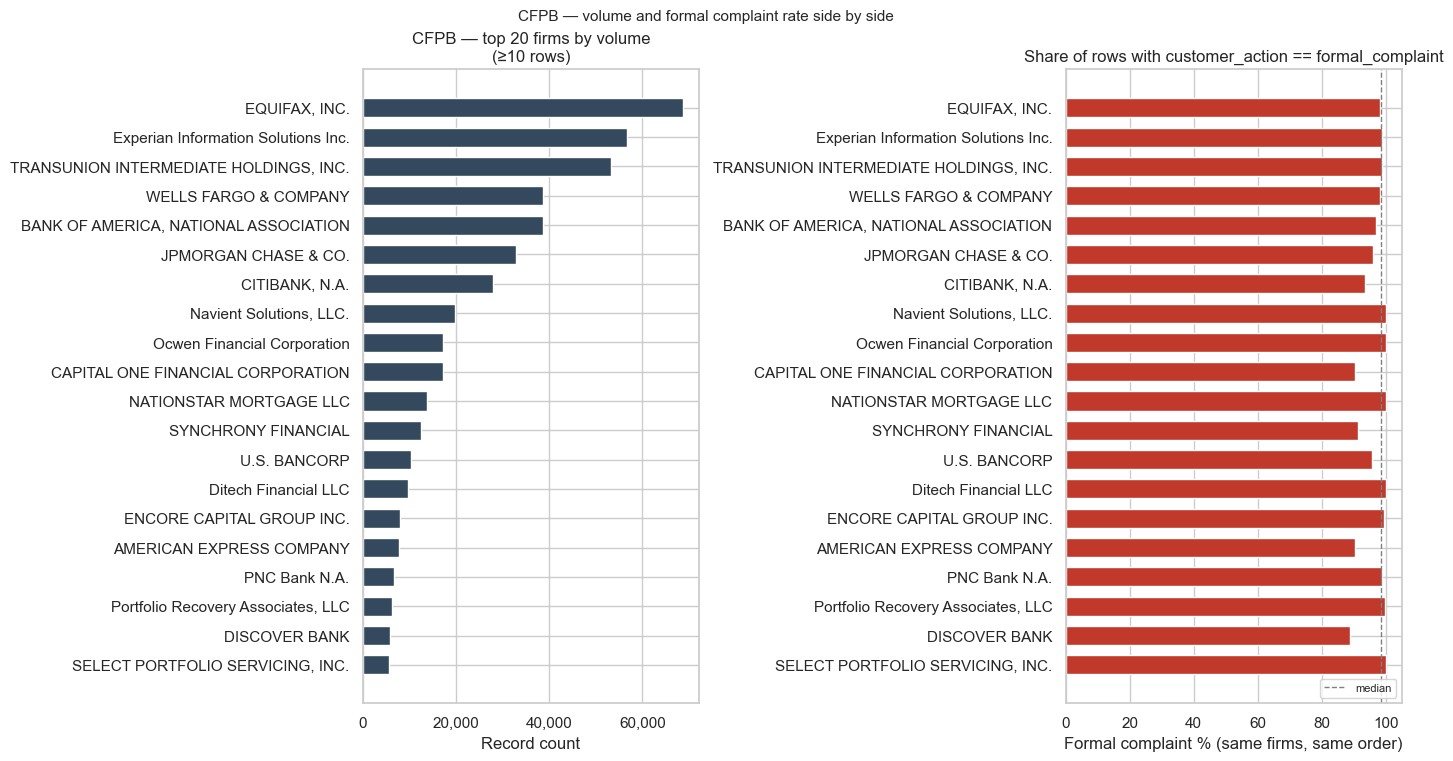

In [35]:
# =============================================================================
# BI charts — run after dfCust exists (matplotlib + seaborn)
# =============================================================================
import textwrap

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# CFPB-only — same slice as Marketing intelligence descriptives (sections 1–4).
_n_all = len(dfCust)
df = dfCust.loc[dfCust["source"].astype(str) == "CFPB"].copy()
print(f"BI charts: CFPB-only, n = {len(df):,} rows (dfCust all sources: {_n_all:,})\n")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["axes.titlesize"] = 12


def _short_company(name, max_len=42):
    s = str(name)
    return s if len(s) <= max_len else s[: max_len - 1] + "…"


# --- 1) Record volume by calendar quarter (CFPB slice, full date range in slice) ---
# Parse dates; fall back to year+month if needed so quarters cover the whole frame.
dt = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
if dt.isna().sum() > len(df) * 0.05:
    dt = pd.to_datetime(
        dict(year=df["year"], month=df["month"], day=1),
        errors="coerce",
    )
quarter_period = dt.dt.to_period("Q")
qvol = quarter_period.dropna().value_counts().sort_index()
if qvol.empty:
    raise ValueError("No valid dates to build quarters — check date/year/month columns.")
q_labels = [str(p) for p in qvol.index]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(range(len(qvol)), qvol.values, color="#2c3e50", edgecolor="white", linewidth=0.5)
ax.set_xticks(range(len(qvol)))
ax.set_xticklabels(q_labels, rotation=45, ha="right", fontsize=9)
ax.set_title("CFPB — record volume by quarter (full date range in slice)")
ax.set_xlabel("Calendar quarter")
ax.set_ylabel("Number of records")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.show()

# --- 2) customer_action mix (% of rows) — behavior, not NLP "positive/negative" ---
act_pct = (
    df["customer_action"].value_counts(normalize=True).mul(100).round(2).sort_values()
)
fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(act_pct))))
colors = sns.color_palette("husl", n_colors=len(act_pct))
ax.barh(act_pct.index.astype(str), act_pct.values, color=colors)
ax.set_xlabel("Share of rows (%)")
ax.set_title("CFPB — customer_action mix (what the row represents)")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.1f}"))
plt.tight_layout()
plt.show()

# --- 3) Top product_service — own figure, wrapped labels (readability) ---
n_prod = min(12, df["product_service"].nunique())
top_prod = df["product_service"].value_counts().head(n_prod).sort_values()
# Wrap long category names for y-axis
prod_labels = [
    textwrap.fill(str(idx), width=36, break_long_words=False) for idx in top_prod.index
]
fig, ax = plt.subplots(figsize=(10, max(5, 0.45 * len(top_prod))))
ax.barh(prod_labels, top_prod.values, color="#27ae60", height=0.75)
ax.set_title(
    f"CFPB — top product_service by row count ({len(top_prod)} of {df['product_service'].nunique()} categories)"
)
ax.set_xlabel("Records")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.show()

# --- 3b) event_type on its own figure; if one category, show note + source breakdown ---
evt = df["event_type"].value_counts().sort_values()
if len(evt) <= 1:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.axis("off")
    ax.text(
        0.5,
        0.55,
        f"Single event_type in this slice:\n{evt.index[0]!r}\n({int(evt.iloc[0]):,} rows)",
        ha="center",
        va="center",
        fontsize=13,
        transform=ax.transAxes,
    )
    ax.set_title("CFPB — event_type (single category in this slice)")
    plt.tight_layout()
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * len(evt))))
    evt_labels = [textwrap.fill(str(i), width=32, break_long_words=False) for i in evt.index]
    ax.barh(evt_labels, evt.values, color="#e67e22", height=0.75)
    ax.set_title("CFPB — event_type (row counts)")
    ax.set_xlabel("Records")
    plt.tight_layout()
    plt.show()

# --- 4) Top 15 companies by volume ---
top_co = df["company"].value_counts().head(15).sort_values()
co_labels = [_short_company(c) for c in top_co.index]
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(co_labels, top_co.values, color="#8e44ad", height=0.72)
ax.set_title("CFPB — top 15 companies by record count")
ax.set_xlabel("Records")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.show()

# --- 5) High-volume firms: record count vs formal_complaint % (presentation-friendly) ---
MIN_ROWS = 10
is_fc = df["customer_action"].astype(str) == "formal_complaint"
comp_stats = (
    df.assign(_fc=is_fc)
    .groupby("company", observed=True)
    .agg(
        n=("_fc", "size"),
        formal_complaint_pct=("_fc", lambda s: np.round(100 * float(s.mean()), 2)),
    )
)
comp_stats = comp_stats[comp_stats["n"] >= MIN_ROWS].copy()
top_vol = comp_stats.sort_values("n", ascending=False).head(20).sort_values("n")
labels = [_short_company(c) for c in top_vol.index]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 7.5),
    gridspec_kw={"width_ratios": [1, 1]},
    constrained_layout=True,
)
axes[0].barh(labels, top_vol["n"], color="#34495e", height=0.65)
axes[0].set_xlabel("Record count")
axes[0].set_title(f"CFPB — top {len(top_vol)} firms by volume\n(≥{MIN_ROWS} rows)")
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

axes[1].barh(labels, top_vol["formal_complaint_pct"], color="#c0392b", height=0.65)
axes[1].set_xlabel("Formal complaint % (same firms, same order)")
axes[1].set_title("Share of rows with customer_action == formal_complaint")
axes[1].axvline(
    top_vol["formal_complaint_pct"].median(),
    color="gray",
    linestyle="--",
    linewidth=1,
    label="median",
)
axes[1].legend(loc="lower right", fontsize=8)

fig.suptitle("CFPB — volume and formal complaint rate side by side", fontsize=11)
plt.show()
